In [1]:
import pandas as pd
import numpy as np

# Load raw data 
seasons = {
    "2018-19": "data/season-1819.csv",
    "2019-20": "data/season-1920.csv",
    "2020-21": "data/season-2021.csv",
    "2021-22": "data/season-2122.csv",
    "2022-23": "data/season-2223.csv",
}

dfs = []
for season, path in seasons.items():
    df = pd.read_csv(path)
    df["Season"] = season
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

cols = ["Season", "Date", "HomeTeam", "AwayTeam",
        "FTHG", "FTAG", "FTR",
        "HS", "AS", "HST", "AST",
        "HC", "AC", "HY", "AY", "HR", "AR"]

df = data[cols].copy()

df.rename(columns={
    "FTHG": "HomeGoals", "FTAG": "AwayGoals", "FTR": "Result",
    "HS": "HomeShots", "AS": "AwayShots",
    "HST": "HomeShotsTarget", "AST": "AwayShotsTarget",
    "HC": "HomeCorners", "AC": "AwayCorners"
}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)
df.dropna(inplace=True)

print(df.shape)
df.head()

(1900, 17)


,Season,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Result,HomeShots,AwayShots,HomeShotsTarget,AwayShotsTarget,HomeCorners,AwayCorners,HY,AY,HR,AR
0,2018-19,2018-08-10,Man United,Leicester,2,1,H,8,13,6,4,2,5,2,1,0,0
1,2018-19,2018-08-11,Bournemouth,Cardiff,2,0,H,12,10,4,1,7,4,1,1,0,0
2,2018-19,2018-08-11,Fulham,Crystal Palace,0,2,A,15,10,6,9,5,5,1,2,0,0
3,2018-19,2018-08-11,Huddersfield,Chelsea,0,3,A,6,13,1,4,2,5,2,1,0,0
4,2018-19,2018-08-11,Newcastle,Tottenham,1,2,A,15,15,2,5,3,5,2,2,0,0


In [2]:
def get_rolling_features(df, window=5):
    records = []
    
    for _, row in df.iterrows():
        # Store the match from home team's perspective
        records.append({
            "Date": row["Date"],
            "Team": row["HomeTeam"],
            "GoalsScored": row["HomeGoals"],
            "GoalsConceded": row["AwayGoals"],
            "ShotsFor": row["HomeShots"],
            "ShotsOnTargetFor": row["HomeShotsTarget"],
            "Win": 1 if row["Result"] == "H" else 0,
            "Draw": 1 if row["Result"] == "D" else 0
        })
        
        records.append({
            "Date": row["Date"],
            "Team": row["AwayTeam"],
            "GoalsScored": row["AwayGoals"],
            "GoalsConceded": row["HomeGoals"],
            "ShotsFor": row["AwayShots"],
            "ShotsOnTargetFor": row["AwayShotsTarget"],
            "Win": 1 if row["Result"] == "A" else 0,
            "Draw": 1 if row["Result"] == "D" else 0
        })
    
    team_records = pd.DataFrame(records).sort_values(["Team", "Date"])
    
    # Calculate rolling averages over last 5 games per team
    team_records["AvgGoalsScored"]     = team_records.groupby("Team")["GoalsScored"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_records["AvgGoalsConceded"]   = team_records.groupby("Team")["GoalsConceded"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_records["AvgShotsFor"]        = team_records.groupby("Team")["ShotsFor"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_records["AvgShotsOnTarget"]   = team_records.groupby("Team")["ShotsOnTargetFor"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_records["WinRate"]            = team_records.groupby("Team")["Win"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    team_records["DrawRate"]           = team_records.groupby("Team")["Draw"].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    
    return team_records

team_stats = get_rolling_features(df)
print(team_stats.shape)
team_stats.head(10)

(3800, 14)


,Date,Team,GoalsScored,GoalsConceded,ShotsFor,ShotsOnTargetFor,Win,Draw,AvgGoalsScored,AvgGoalsConceded,AvgShotsFor,AvgShotsOnTarget,WinRate,DrawRate
14,2018-08-12,Arsenal,0,2,9,3,0,0,NaN,NaN,NaN,NaN,NaN,NaN
27,2018-08-18,Arsenal,2,3,15,6,0,0,0.000000,2.0,9.000000,3.000000,0.000000,0.0
40,2018-08-25,Arsenal,3,1,17,10,1,0,1.000000,2.5,12.000000,4.500000,0.000000,0.0
77,2018-09-02,Arsenal,3,2,17,11,1,0,1.666667,2.0,13.666667,6.333333,0.333333,0.0
87,2018-09-15,Arsenal,2,1,12,2,1,0,2.000000,2.0,14.500000,7.500000,0.500000,0.0
118,2018-09-23,Arsenal,2,0,9,5,1,0,2.000000,1.8,14.000000,6.400000,0.600000,0.0
120,2018-09-29,Arsenal,2,0,9,2,1,0,2.400000,1.4,14.000000,6.800000,0.800000,0.0
155,2018-10-07,Arsenal,5,1,9,7,1,0,2.400000,0.8,12.800000,6.000000,1.000000,0.0
178,2018-10-22,Arsenal,3,1,19,6,1,0,2.800000,0.8,11.200000,5.400000,1.000000,0.0
195,2018-10-28,Arsenal,2,2,7,2,0,1,2.800000,0.6,11.600000,4.400000,1.000000,0.0


In [3]:
# Separate home and away stats
home_stats = team_stats[["Date", "Team", "AvgGoalsScored", "AvgGoalsConceded", 
                          "AvgShotsFor", "AvgShotsOnTarget", "WinRate", "DrawRate"]].copy()

away_stats = home_stats.copy()

# Rename columns 
home_stats.columns = ["Date", "HomeTeam", "Home_AvgGoalsScored", "Home_AvgGoalsConceded",
                      "Home_AvgShotsFor", "Home_AvgShotsOnTarget", "Home_WinRate", "Home_DrawRate"]

away_stats.columns = ["Date", "AwayTeam", "Away_AvgGoalsScored", "Away_AvgGoalsConceded",
                      "Away_AvgShotsFor", "Away_AvgShotsOnTarget", "Away_WinRate", "Away_DrawRate"]

# Merge onto main dataframe
df_model = df.merge(home_stats, on=["Date", "HomeTeam"], how="left")
df_model = df_model.merge(away_stats, on=["Date", "AwayTeam"], how="left")

df_model.dropna(inplace=True)

print(df_model.shape)
print(df_model.columns.tolist())

(1883, 29)
['Season', 'Date', 'HomeTeam', 'AwayTeam', 'HomeGoals', 'AwayGoals', 'Result', 'HomeShots', 'AwayShots', 'HomeShotsTarget', 'AwayShotsTarget', 'HomeCorners', 'AwayCorners', 'HY', 'AY', 'HR', 'AR', 'Home_AvgGoalsScored', 'Home_AvgGoalsConceded', 'Home_AvgShotsFor', 'Home_AvgShotsOnTarget', 'Home_WinRate', 'Home_DrawRate', 'Away_AvgGoalsScored', 'Away_AvgGoalsConceded', 'Away_AvgShotsFor', 'Away_AvgShotsOnTarget', 'Away_WinRate', 'Away_DrawRate']


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Only use pre-match rolling features
features = [
    "Home_AvgGoalsScored", "Home_AvgGoalsConceded",
    "Home_AvgShotsFor", "Home_AvgShotsOnTarget",
    "Home_WinRate", "Home_DrawRate",
    "Away_AvgGoalsScored", "Away_AvgGoalsConceded",
    "Away_AvgShotsFor", "Away_AvgShotsOnTarget",
    "Away_WinRate", "Away_DrawRate"
]

X = df_model[features]
y = df_model["Result"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified K-Fold cross validation 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=1000, C=0.5,
                           class_weight="balanced",
                           random_state=42)

scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")

print(f"Fold accuracies: {scores.round(4)}")
print(f"Mean accuracy:   {scores.mean():.2%}")
print(f"Std deviation:   {scores.std():.2%}")

Fold accuracies: [0.4271 0.5358 0.4403 0.4814 0.484 ]
Mean accuracy:   47.37%
Std deviation:   3.82%


In [5]:
df_model["GoalsDiff"]      = df_model["Home_AvgGoalsScored"] - df_model["Away_AvgGoalsScored"]
df_model["DefenceDiff"]    = df_model["Home_AvgGoalsConceded"] - df_model["Away_AvgGoalsConceded"]
df_model["ShotsDiff"]      = df_model["Home_AvgShotsFor"] - df_model["Away_AvgShotsFor"]
df_model["ShotsTargetDiff"]= df_model["Home_AvgShotsOnTarget"] - df_model["Away_AvgShotsOnTarget"]
df_model["WinRateDiff"]    = df_model["Home_WinRate"] - df_model["Away_WinRate"]
df_model["DrawRateDiff"]   = df_model["Home_DrawRate"] - df_model["Away_DrawRate"]

features = [
    "Home_AvgGoalsScored", "Home_AvgGoalsConceded",
    "Home_AvgShotsFor", "Home_AvgShotsOnTarget",
    "Home_WinRate", "Home_DrawRate",
    "Away_AvgGoalsScored", "Away_AvgGoalsConceded",
    "Away_AvgShotsFor", "Away_AvgShotsOnTarget",
    "Away_WinRate", "Away_DrawRate",
    "GoalsDiff", "DefenceDiff", "ShotsDiff",
    "ShotsTargetDiff", "WinRateDiff", "DrawRateDiff"
]

X = df_model[features]
y = df_model["Result"]

X_scaled = scaler.fit_transform(X)

scores = cross_val_score(model, X_scaled, y, cv=skf, scoring="accuracy")

print(f"Fold accuracies: {scores.round(4)}")
print(f"Mean accuracy:   {scores.mean():.2%}")
print(f"Std deviation:   {scores.std():.2%}")

Fold accuracies: [0.4271 0.5358 0.4403 0.4787 0.484 ]
Mean accuracy:   47.32%
Std deviation:   3.82%


In [6]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target for XGBoost
le = LabelEncoder()
y_encoded = le.fit_transform(y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.5,
                                               class_weight="balanced",
                                               random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200,
                                                   max_depth=10,
                                                   class_weight="balanced",
                                                   random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200,
                                          max_depth=5,
                                          learning_rate=0.05,
                                          
                                          eval_metric="mlogloss",
                                          random_state=42)
}

print("Model Comparison (Stratified 5-Fold CV)\n")
print(f"{'Model':<25} {'Mean Accuracy':>15} {'Std Dev':>10}")
print("-" * 52)

for name, m in models.items():
    y_input = y_encoded if name == "XGBoost" else y
    scores = cross_val_score(m, X_scaled, y_input, cv=skf, scoring="accuracy")
    print(f"{name:<25} {scores.mean():>14.2%} {scores.std():>9.2%}")

Model Comparison (Stratified 5-Fold CV)

Model                       Mean Accuracy    Std Dev
----------------------------------------------------
Logistic Regression               47.32%     3.82%
Random Forest                     47.80%     1.81%
XGBoost                           48.80%     1.38%


In [7]:
from sklearn.metrics import classification_report, log_loss

# Final model on full data with train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

best_model = RandomForestClassifier(n_estimators=200,
                                     max_depth=10,
                                     class_weight="balanced",
                                     random_state=42)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"Log Loss:  {log_loss(y_test, y_prob):.4f}")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Accuracy:  46.68%
Log Loss:  1.0531

Detailed report:
              precision    recall  f1-score   support

           A       0.43      0.57      0.49       126
           D       0.25      0.20      0.22        84
           H       0.61      0.52      0.56       167

    accuracy                           0.47       377
   macro avg       0.43      0.43      0.43       377
weighted avg       0.47      0.47      0.46       377



In [ ]:
pip install shap

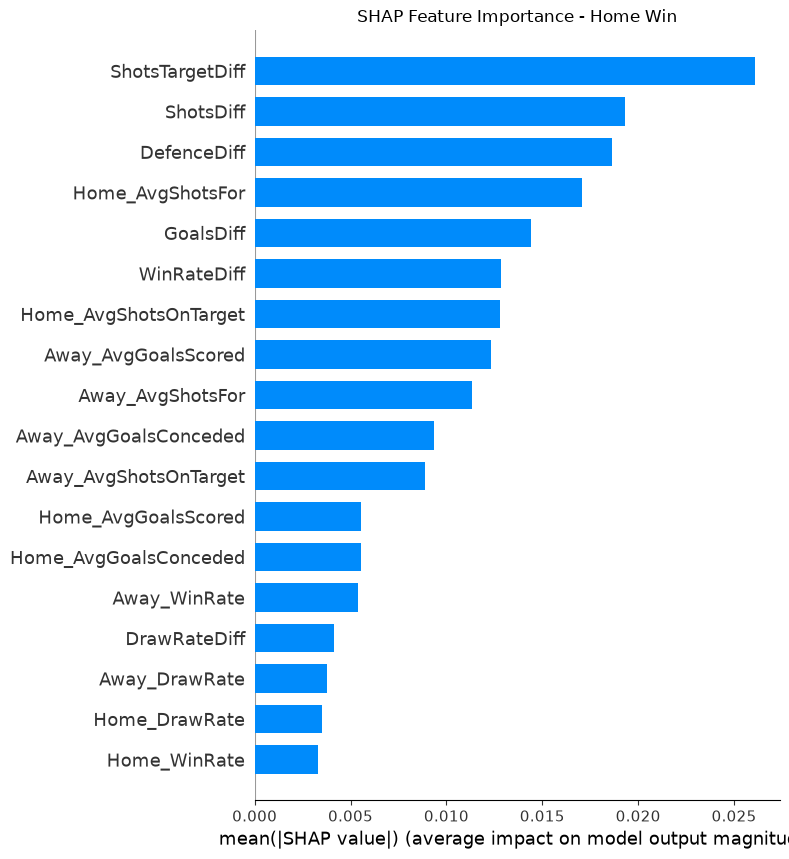

SHAP plot saved!


In [8]:
import shap
import matplotlib.pyplot as plt

# SHAP explainer for Random Forest
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Convert features to dataframe for readable labels
X_test_df = pd.DataFrame(X_test, columns=features)

# Plot 1 - Feature importance summary for Home Win (H)
plt.figure()
shap.summary_plot(shap_values[:, :, 2], X_test_df, 
                  plot_type="bar", 
                  show=False)
plt.title("SHAP Feature Importance - Home Win")
plt.tight_layout()
plt.savefig("outputs/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved!")